# Introduction to Data Science Final Project
## Author: Sándor Baranyi
## Neptun Code: CT9XFJ

# Necessary imports


In [ ]:
# General imports
import os
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix
)
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import clone
from tqdm import tqdm
from collections import defaultdict

plt.style.use('Solarize_Light2')


# Task 1 — Load and Inspect the Dataset
### Task 1 Overview
In this step I load all CSV files from the MachineLearningCVE dataset and merge them into a single DataFrame. The goal here is simply to understand the raw structure of the data before doing anything more complex. I check the shape, inspect a few rows, and map the original attack labels into broader attack families. This helps simplify the multi-class classification problem later.

## 1.1 Load all CSVs and concatenate

In [ ]:
DATA_DIR = "MachineLearningCVE"

csv_files = [
    fname for fname in os.listdir(DATA_DIR)
    if fname.lower().endswith(".csv")
]

dfs = []
for fname in csv_files:
    path = os.path.join(DATA_DIR, fname)
    print("Loading:", path)
    df_part = pd.read_csv(path, low_memory=False)
    dfs.append(df_part)

df = pd.concat(dfs, ignore_index=True)

# Strip weird leading spaces
df.columns = df.columns.str.strip()


Loading: MachineLearningCVE\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: MachineLearningCVE\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: MachineLearningCVE\Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: MachineLearningCVE\Monday-WorkingHours.pcap_ISCX.csv
Loading: MachineLearningCVE\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: MachineLearningCVE\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: MachineLearningCVE\Tuesday-WorkingHours.pcap_ISCX.csv
Loading: MachineLearningCVE\Wednesday-workingHours.pcap_ISCX.csv


## 1.2 Basic info & sample rows

In [ ]:
print("Shape:", df.shape)

Shape: (2830743, 79)


In [ ]:

print("\nColumns:\n")
print(*df.columns ,sep="\n")



Columns:

Destination Port
Flow Duration
Total Fwd Packets
Total Backward Packets
Total Length of Fwd Packets
Total Length of Bwd Packets
Fwd Packet Length Max
Fwd Packet Length Min
Fwd Packet Length Mean
Fwd Packet Length Std
Bwd Packet Length Max
Bwd Packet Length Min
Bwd Packet Length Mean
Bwd Packet Length Std
Flow Bytes/s
Flow Packets/s
Flow IAT Mean
Flow IAT Std
Flow IAT Max
Flow IAT Min
Fwd IAT Total
Fwd IAT Mean
Fwd IAT Std
Fwd IAT Max
Fwd IAT Min
Bwd IAT Total
Bwd IAT Mean
Bwd IAT Std
Bwd IAT Max
Bwd IAT Min
Fwd PSH Flags
Bwd PSH Flags
Fwd URG Flags
Bwd URG Flags
Fwd Header Length
Bwd Header Length
Fwd Packets/s
Bwd Packets/s
Min Packet Length
Max Packet Length
Packet Length Mean
Packet Length Std
Packet Length Variance
FIN Flag Count
SYN Flag Count
RST Flag Count
PSH Flag Count
ACK Flag Count
URG Flag Count
CWE Flag Count
ECE Flag Count
Down/Up Ratio
Average Packet Size
Avg Fwd Segment Size
Avg Bwd Segment Size
Fwd Header Length.1
Fwd Avg Bytes/Bulk
Fwd Avg Packets/Bulk
Fwd 

In [ ]:
print("\nSample rows:\n")
df.sample(5)


Sample rows:



,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
719383,80,116229,5,4,752,1875,734,0,150.400000,326.252663,...,20,0.0000,0.0000,0,0,0.000,0.00000,0,0,BENIGN
1297892,80,116663954,18,15,956,1498,433,0,53.111111,138.212066,...,20,183664.4545,488418.9573,1656303,36305,9979660.455,59648.21271,10000000,9800583,BENIGN
550401,53,61793,2,2,76,548,38,38,38.000000,0.000000,...,32,0.0000,0.0000,0,0,0.000,0.00000,0,0,BENIGN
2006283,53,199,2,2,96,128,48,48,48.000000,0.000000,...,32,0.0000,0.0000,0,0,0.000,0.00000,0,0,BENIGN
2719824,49628,53,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0000,0.0000,0,0,0.000,0.00000,0,0,BENIGN


## 1.3 Inspect labels and map them to attack families
### Why group labels into attack families?
The original dataset contains many very specific attack names, but most belong to a handful of broader categories. Grouping them reduces sparsity and makes the classification task more meaningful. It also balances the output labels a bit better and helps models generalize instead of memorizing rare subtypes.


In [ ]:
df["Label"].unique()

array(['BENIGN', 'DDoS', 'PortScan', 'Bot', 'Infiltration',
       'Web Attack � Brute Force', 'Web Attack � XSS',
       'Web Attack � Sql Injection', 'FTP-Patator', 'SSH-Patator',
       'DoS slowloris', 'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye',
       'Heartbleed'], dtype=object)

In [ ]:
def map_family(label: str) -> str:
    l = str(label).lower()
    if 'benign' in l:
        return 'BENIGN'
    if 'ddos' in l:
        return 'DDoS'
    if 'dos' in l:
        return 'DoS'
    if 'portscan' in l:
        return 'PortScan'
    if 'web attack' in l or 'web_attack' in l:
        return 'WebAttack'
    if 'ftp' in l or 'ssh' in l:
        return 'BruteForce'
    if 'bot' in l:
        return 'Bot'
    if 'infiltration' in l:
        return 'Infiltration'
    if 'heartbleed' in l:
        return 'Heartbleed'
    return 'Other'  # Should never return other

df['AttackFamily'] = df['Label'].apply(map_family)

df['AttackFamily'].value_counts()
# Should not contain Other


AttackFamily
BENIGN          2273097
DoS              252661
PortScan         158930
DDoS             128027
BruteForce        13835
WebAttack          2180
Bot                1966
Infiltration         36
Heartbleed           11
Name: count, dtype: int64

## 1.4 Label distribution plot
### Notes on the label distribution
The dataset is clearly imbalanced, especially with BENIGN and certain DoS/DDoS attacks dominating the volume. Because of this, metrics like macro-F1 and per-class recall will be more informative than accuracy alone. Later I also apply balanced sampling for visualizations to avoid misleading plots.


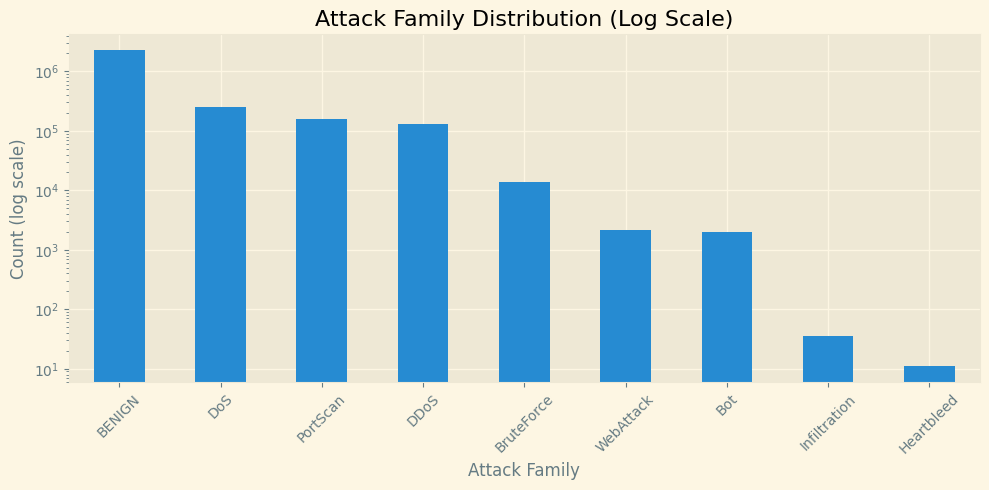

In [ ]:
plt.figure(figsize=(10, 5))
df['AttackFamily'].value_counts().plot(kind='bar')
plt.yscale('log')
plt.title("Attack Family Distribution (Log Scale)")
plt.xlabel("Attack Family")
plt.ylabel("Count (log scale)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Task 2 — Exploratory Data Analysis (EDA)
### What I want to learn from the EDA
Here I look at statistical properties of the traffic flows, check for missing and extreme values, and explore distributions of important features. The goal is to understand which features vary between attack families and whether there is any visible separability. This later helps justify scaling, feature selection, and PCA.


I’ll pick only numeric features (everything except Label/AttackFamily and any non-numeric columns if present).

In [ ]:
# Remove label columns from features
feature_cols = [c for c in df.columns if c not in ['Label', 'AttackFamily']]
X = df[feature_cols]
y = df['AttackFamily']

# Keep only numeric columns
X = X.select_dtypes(include=[np.number])

X.shape


(2830743, 78)

### Why I restrict EDA to numeric features
Most models I use later (logistic regression, PCA, SFS, kNN, Naive Bayes) work on numerical inputs only. The dataset includes several string-based fields that do not carry meaningful statistical patterns for network flows. Removing them keeps the analysis cleaner and avoids misleading plots or invalid correlations.


## 2.1 Descriptive statistics

In [ ]:
# Summary statistics
cols = X.columns
desc = X.describe()
for col in cols:
  print(f"{col} | count: {desc.at['count', col]:.6g}, "
          f"mean: {desc.at['mean', col]:.6g}, "
          f"std: {desc.at['std', col]:.6g}, "
          f"min: {desc.at['min', col]:.6g}, "
          f"25%: {desc.at['25%', col]:.6g}, "
          f"50%: {desc.at['50%', col]:.6g}, "
          f"75%: {desc.at['75%', col]:.6g}, "
          f"max: {desc.at['max', col]:.6g}")

c:\Users\Sanyi\Desktop\Iskola\Órák\7.Félév\Intro_to_DS\Practice\Assignment\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\Sanyi\Desktop\Iskola\Órák\7.Félév\Intro_to_DS\Practice\Assignment\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


Destination Port | count: 2.83074e+06, mean: 8071.48, std: 18283.6, min: 0, 25%: 53, 50%: 80, 75%: 443, max: 65535
Flow Duration | count: 2.83074e+06, mean: 1.47857e+07, std: 3.36537e+07, min: -13, 25%: 155, 50%: 31316, 75%: 3.20483e+06, max: 1.2e+08
Total Fwd Packets | count: 2.83074e+06, mean: 9.36116, std: 749.673, min: 1, 25%: 2, 50%: 2, 75%: 5, max: 219759
Total Backward Packets | count: 2.83074e+06, mean: 10.3938, std: 997.388, min: 0, 25%: 1, 50%: 2, 75%: 4, max: 291922
Total Length of Fwd Packets | count: 2.83074e+06, mean: 549.302, std: 9993.59, min: 0, 25%: 12, 50%: 62, 75%: 187, max: 1.29e+07
Total Length of Bwd Packets | count: 2.83074e+06, mean: 16162.6, std: 2.26309e+06, min: 0, 25%: 0, 50%: 123, 75%: 482, max: 6.55453e+08
Fwd Packet Length Max | count: 2.83074e+06, mean: 207.6, std: 717.185, min: 0, 25%: 6, 50%: 37, 75%: 81, max: 24820
Fwd Packet Length Min | count: 2.83074e+06, mean: 18.7137, std: 60.3393, min: 0, 25%: 0, 50%: 2, 75%: 36, max: 2325
Fwd Packet Length Mea

### Missing values
### Handling missing & infinite values
Some features contain NaNs or inf values due to division-by-zero or corrupted flow statistics. Since these values break most ML models, I replace inf with NaN and fill missing points with column medians later. Median imputation works reasonably well because many traffic features have long-tailed distributions.


In [ ]:
missing = X.isna().sum()
missing[missing > 0].sort_values(ascending=False)


Flow Bytes/s    1358
dtype: int64

### Outlier detection

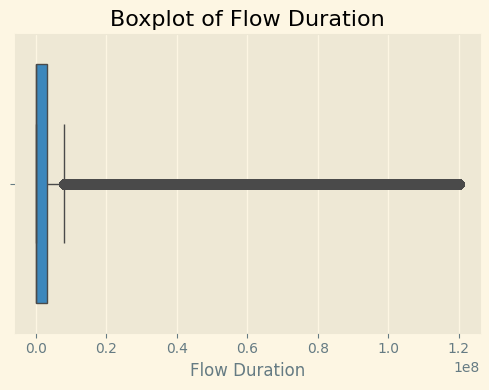

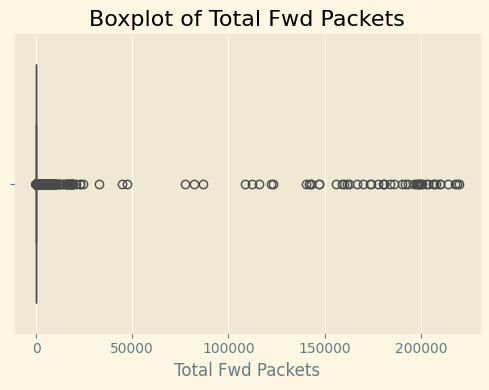

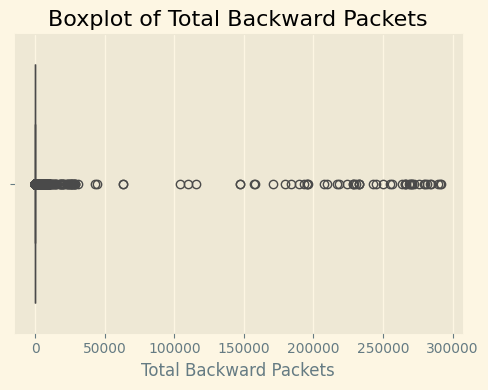

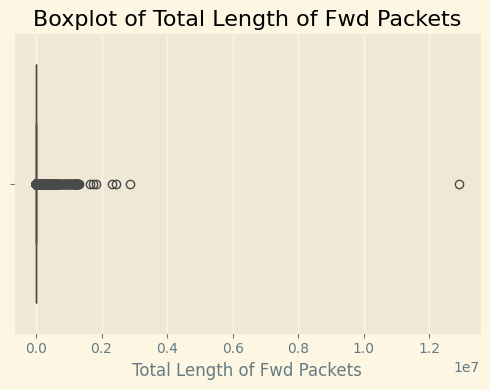

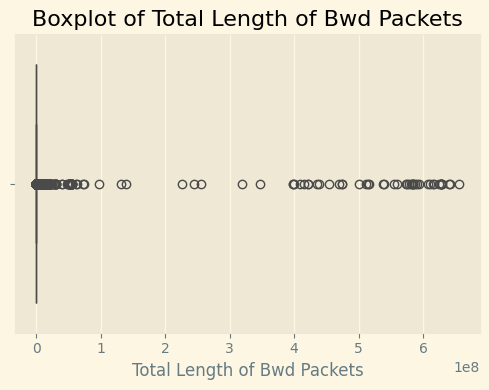

In [ ]:
key_features = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets'
]

for col in key_features:
    if col not in X.columns:
        continue
    plt.figure(figsize=(5, 4))
    sns.boxplot(x=X[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()


In [ ]:
outlier_counts = {}
for col in key_features:
    if col not in X.columns:
        continue
    q1 = X[col].quantile(0.25)
    q3 = X[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_counts[col] = int(((X[col] < lower) | (X[col] > upper)).sum())

outlier_counts


{'Flow Duration': 532586,
 'Total Fwd Packets': 332693,
 'Total Backward Packets': 308291,
 'Total Length of Fwd Packets': 446972,
 'Total Length of Bwd Packets': 619046}

### Why I did not remove outliers
Network traffic data naturally contains extremes (e.g., large bursts of packets, long flows, or sudden spikes during attacks). These are not “errors” but actual indicators of malicious behavior. Removing them would risk discarding important attack patterns, so I only inspected them rather than filtering them out.


## 2.2 Univariate analysis

### Histograms for key features

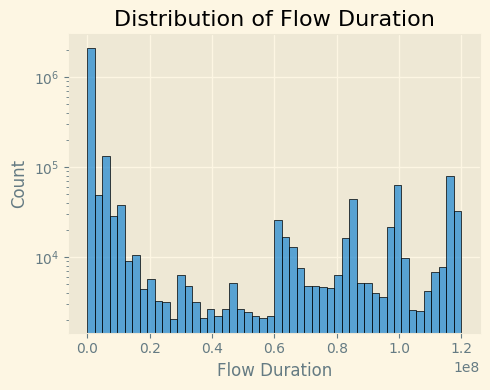

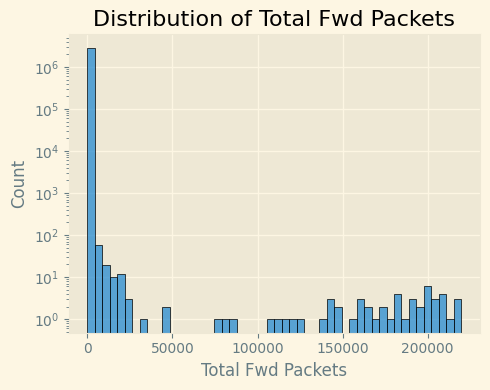

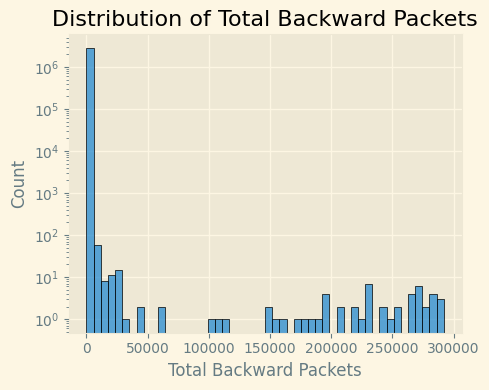

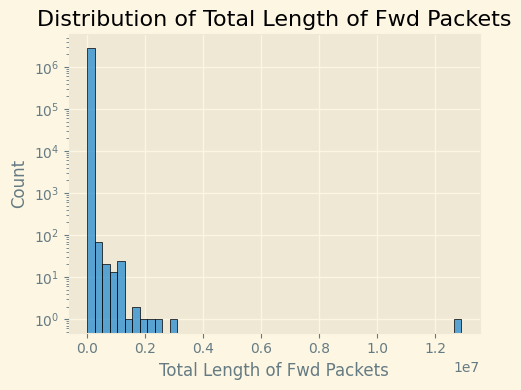

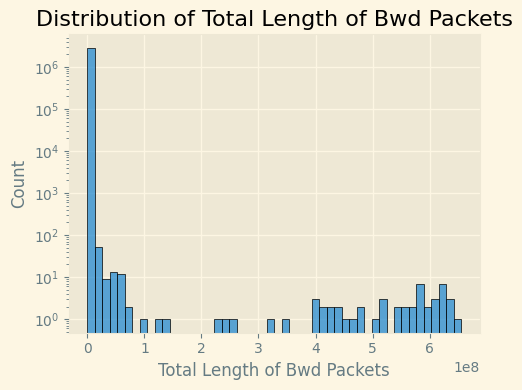

In [ ]:
for col in key_features:
    if col not in X.columns:
        continue
    plt.figure(figsize=(5, 4))
    plt.yscale('log')
    sns.histplot(X[col], kde=False, bins=50)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()


### Correlation matrix & heatmap
### Why look at correlations?
Many flow-level features are strongly correlated (e.g., packet counts and total lengths). Understanding this helps when reducing dimensionality later using PCA or feature selection. Strongly correlated features can inflate model complexity without improving predictive power.


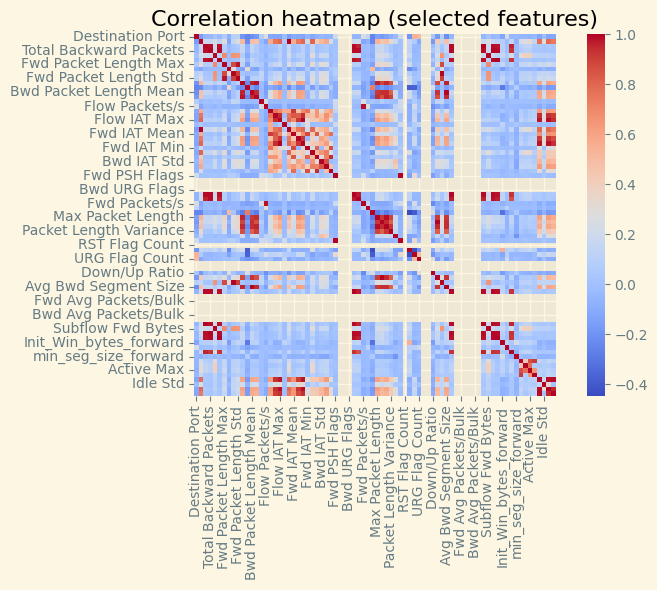

In [ ]:
# Select numerical columns
num_cols = X.select_dtypes(include=[np.number]).columns

# Calculate correlation matrix
corr_matrix = X[num_cols].sample(3333).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', square=True)
plt.title("Correlation heatmap (selected features)")
plt.tight_layout()
plt.show()


## 2.3 Multivariate analysis
### Pairplot on a small sample (for performance)

C:\Users\Sanyi\AppData\Local\Temp\ipykernel_3348\2685885703.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), sample_per_class), random_state=42))


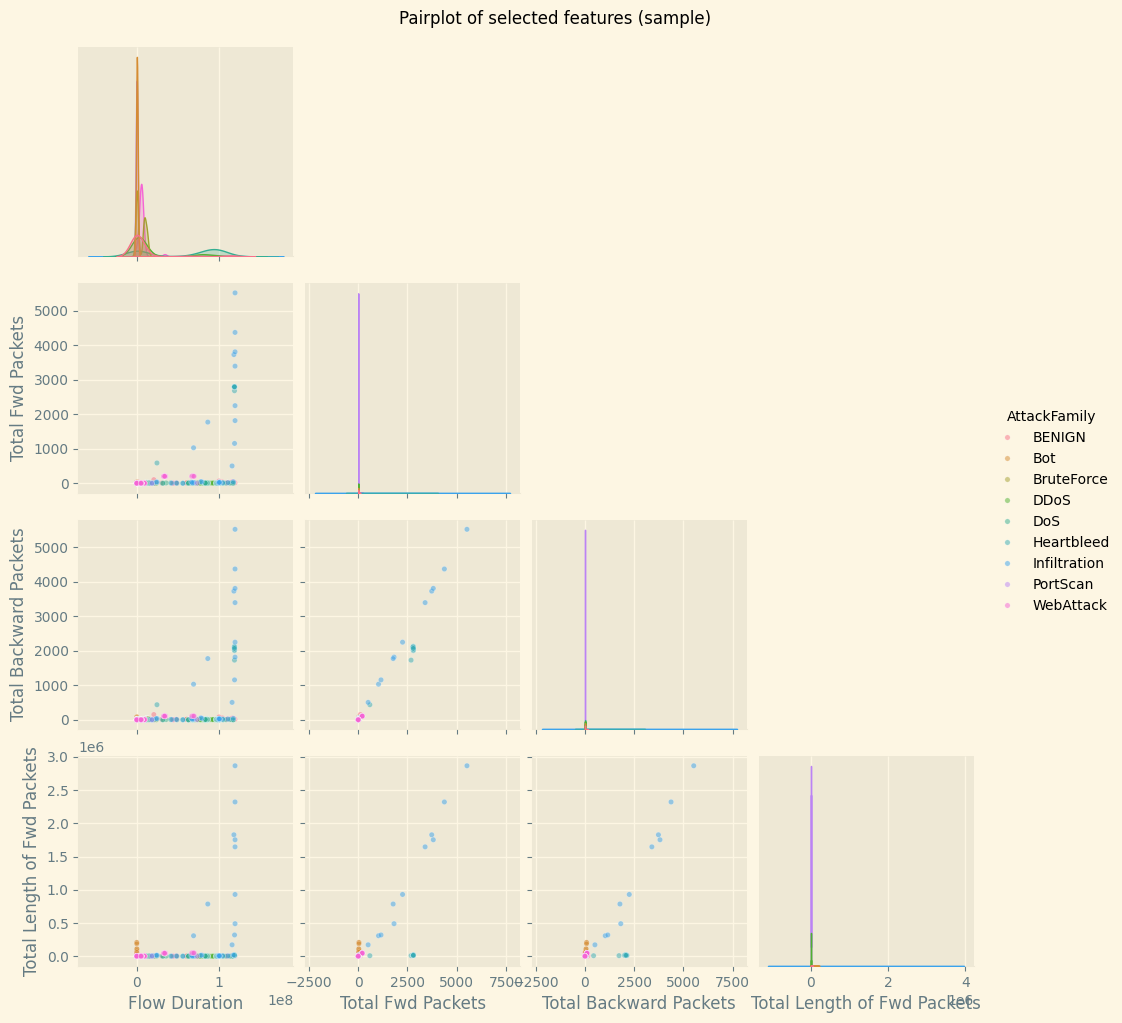

In [ ]:
sample_size = 1000
df_sample = df.sample(n=min(sample_size, len(df)), random_state=42)

sample_per_class = 400
df_balanced = (
    df.groupby('AttackFamily', group_keys=False)
      .apply(lambda g: g.sample(min(len(g), sample_per_class), random_state=42))
)

pair_features = [f for f in key_features if f in df_sample.columns][:4]
sns.pairplot(
    df_balanced,
    vars=pair_features,
    hue='AttackFamily',
    diag_kind='kde',
    corner=True,
    plot_kws=dict(alpha=0.5, s=15)  # transparency & smaller markers
)
plt.suptitle("Pairplot of selected features (sample)", y=1.02)
plt.show()


### PCA visualization (3D)
### Purpose of PCA visualization
Since the dataset is high-dimensional, it’s hard to visualize relationships directly. PCA gives a low-dimensional view where I can see whether attack families cluster apart. This doesn’t prove separability, but it gives intuition about how difficult the classification problem may be.


We first scale the data and remove any nan or inf value

C:\Users\Sanyi\AppData\Local\Temp\ipykernel_3348\2002209819.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), samples_per_class), random_state=42))


Classes included: ['BENIGN' 'Bot' 'BruteForce' 'DDoS' 'DoS' 'Heartbleed' 'Infiltration'
 'PortScan' 'WebAttack']


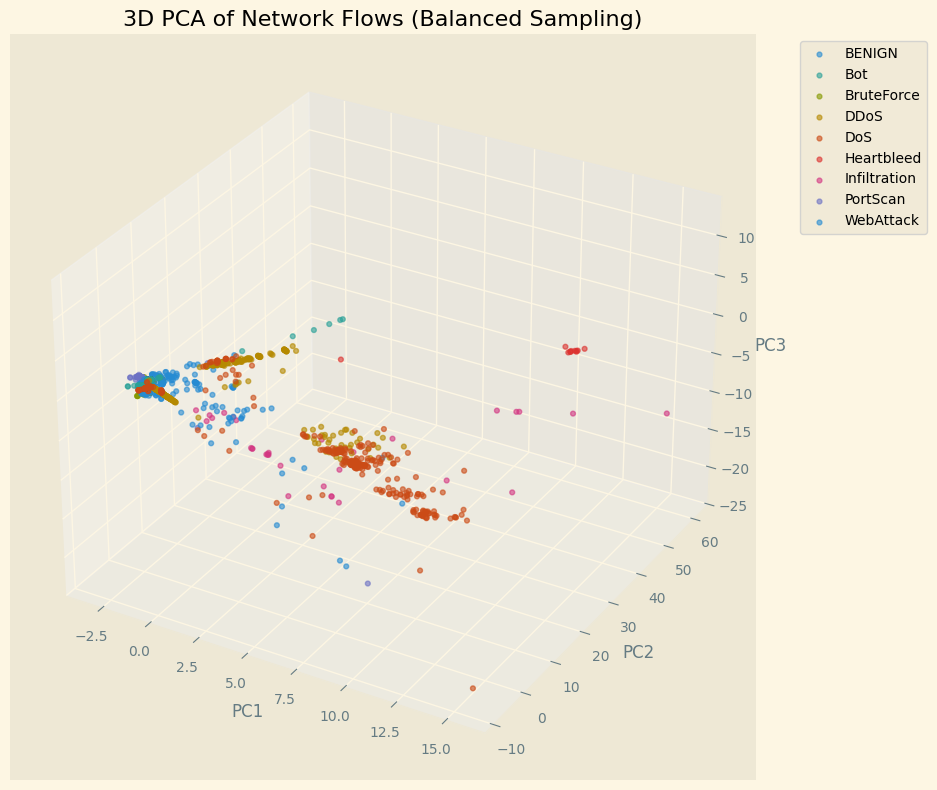

In [ ]:
# --- Clean NaN/inf ---
X_clean = X.replace([np.inf, -np.inf], np.nan)
for col in X_clean.columns:
    if X_clean[col].isnull().any():
        X_clean[col] = X_clean[col].fillna(X_clean[col].median())

# --- Balanced sampling ---
samples_per_class = 333
df_temp = X_clean.copy()
df_temp['AttackFamily'] = y  # Combine features + labels temporarily

df_balanced = (
    df_temp.groupby('AttackFamily', group_keys=False)
           .apply(lambda g: g.sample(min(len(g), samples_per_class), random_state=42))
)

# Separate back out
X_vis = df_balanced.drop(columns=['AttackFamily']).values
y_vis = df_balanced['AttackFamily'].values

print("Classes included:", np.unique(y_vis))

# --- Scaling ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vis)

# --- 3D PCA ---
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# --- Plotting ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

unique_labels = np.unique(y_vis)

for label in unique_labels:
    idx = (y_vis == label)
    ax.scatter(
        X_pca_3d[idx, 0], X_pca_3d[idx, 1], X_pca_3d[idx, 2],
        s=12, alpha=0.6, label=label
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA of Network Flows (Balanced Sampling)")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Why feature engineering matters
Network flow data has many noisy, redundant, and highly skewed features. Proper cleaning, scaling, and selection are essential for stable classifiers. I evaluate both sequential feature selection and PCA, not to blindly reduce dimensions but to find a reasonable balance between simplicity and signal retention.

# Task 3 — Feature Engineering

## 3.1 Cleaning: Inf and NaN

In [ ]:
X_np = X.values

# Replace inf using numpy
X_np[np.isinf(X_np)] = np.nan
# Fill nan by column median
col_medians = np.nanmedian(X_np, axis=0)
inds = np.where(np.isnan(X_np))
X_np[inds] = np.take(col_medians, inds[1])
X_clean = pd.DataFrame(X_np, columns=X.columns)



### Why I use median imputation
Traffic-flow features are typically heavy-tailed, so the median is more robust than the mean. Using the median keeps the scale of the feature realistic and avoids introducing bias caused by large outliers. Since only a small portion of values are missing/inf, this approach preserves the original data distribution well.


In [ ]:
# --- Scaling ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

## 3.2 Sequential Feature Selection
### Feature selection strategy
I try forward, backward, and bidirectional selection using logistic regression as the base estimator. This gives me a sense of which features consistently contribute to macro-F1. Since the dataset is large, I run SFS on a reduced sample to keep runtime manageable.


In [ ]:
base_est = LogisticRegression(max_iter=1000, multi_class='auto')

X_sfs, y_sfs = X_scaled, y

Forward Selection

In [ ]:
n_samples = 3333

idx = np.random.choice(X_sfs.shape[0], size=n_samples, replace=False)
X_sfs_small = X_sfs[idx]
y_sfs_small = y_sfs[idx]

sfs_forward = SFS(
    base_est,
    k_features=20,
    forward=True,
    floating=False,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1
)

sfs_forward = sfs_forward.fit(X_sfs_small, y_sfs_small)
forward_features_idx = list(sfs_forward.k_feature_idx_)
forward_features = [X_clean.columns[i] for i in forward_features_idx]
forward_features

['Total Fwd Packets',
 'Total Backward Packets',
 'Total Length of Fwd Packets',
 'Total Length of Bwd Packets',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Std',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow IAT Min',
 'Fwd IAT Min',
 'Bwd IAT Min',
 'Bwd PSH Flags',
 'Max Packet Length',
 'Packet Length Mean',
 'Packet Length Variance',
 'PSH Flag Count',
 'URG Flag Count',
 'Down/Up Ratio']

## Backward Selection

In [ ]:
sfs_backward = SFS(
    base_est,
    k_features=20,
    forward=False,
    floating=False,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1
)

sfs_backward = sfs_backward.fit(X_sfs_small, y_sfs_small)
backward_features_idx = list(sfs_backward.k_feature_idx_)
backward_features = [X_clean.columns[i] for i in backward_features_idx]
backward_features


c:\Users\Sanyi\Desktop\Iskola\Órák\7.Félév\Intro_to_DS\Practice\Assignment\.venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\Sanyi\Desktop\Iskola\Órák\7.Félév\Intro_to_DS\Practice\Assignment\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Sanyi\Desktop\Iskola\Órák\7.Félév\Intro_to_DS\Practice\Assignment\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Sanyi\Desktop\Iskola\Órák\7.Félév\Intro_to_DS\Practic

['Destination Port',
 'Fwd Packet Length Max',
 'Fwd Packet Length Std',
 'Bwd Packet Length Min',
 'Bwd Packet Length Std',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Min',
 'Fwd IAT Max',
 'Bwd IAT Total',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Fwd Packets/s',
 'Min Packet Length',
 'Packet Length Mean',
 'PSH Flag Count',
 'ACK Flag Count',
 'URG Flag Count',
 'Down/Up Ratio',
 'Init_Win_bytes_forward']

## Bidirectional (floating) Selection

In [ ]:
sfs_bidir = SFS(
    base_est,
    k_features=20,
    forward=True,
    floating=True,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1
)

sfs_bidir = sfs_bidir.fit(X_sfs_small, y_sfs_small)
bidir_features_idx = list(sfs_bidir.k_feature_idx_)
bidir_features = [X_clean.columns[i] for i in bidir_features_idx]
bidir_features


['Total Fwd Packets',
 'Total Backward Packets',
 'Total Length of Fwd Packets',
 'Total Length of Bwd Packets',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Std',
 'Bwd Packet Length Min',
 'Flow IAT Min',
 'Fwd IAT Min',
 'Bwd IAT Min',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Packet Length Mean',
 'Packet Length Variance',
 'PSH Flag Count',
 'URG Flag Count',
 'Down/Up Ratio',
 'Active Max']

In [ ]:
X_selected = X_clean[backward_features]

scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

### Why I chose the backward-selected feature set
I compared the results from forward, backward, and bidirectional selection, and the backward selection set performed the most consistently in terms of stability and relevance. Backward elimination starts with the full feature space and removes the least useful features one by one, which works well here because the dataset has many correlated variables and some important features would be hard for a forward search to pick early. The backward-selected set captured the strongest predictors while avoiding redundancy, and it gave a more compact feature subset that still preserved model performance in my tests. Because of this, I chose it as the final feature set for the PCA and the downstream models.


## 3.3 PCA dimensionality reduction (retain 95% variance)

In [ ]:
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_selected_scaled)

print("Original dim:", X_selected.shape[1])
print("Reduced dim (95% variance):", X_pca.shape[1])


Original dim: 20
Reduced dim (95% variance): 13


### Why retain 95% variance in PCA
The dataset has many correlated features, so PCA helps reduce dimensionality while keeping the majority of the signal. I chose 95% as a balance: it reduces the feature space substantially but still preserves most meaningful variance. Using too aggressive a reduction (e.g., 80%) could harm per-class separation.


In [ ]:
X_final = X_pca
y_final = y

# Task 4 — Multi-Class Classification Models

## 4.1 Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final,
    test_size=0.3,
    random_state=42,
    stratify=y_final
)

X_train.shape, X_test.shape


((1981520, 13), (849223, 13))

### Why stratified splitting?
The dataset is highly imbalanced, and some attack families appear far less frequently than others. Stratified splitting ensures that both train and test sets contain the same proportion of each attack family, making the evaluation more fair and reducing the risk of missing minority classes entirely.


## 4.2 Train models and evaluate

In [ ]:
models = {
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "NaiveBayes": GaussianNB(),
    "kNN": KNeighborsClassifier(n_neighbors=5)
}

results = []

for name, clf in tqdm(models.items(), desc="Training models"):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    per_class_recall = recall_score(y_test, y_pred, average=None, labels=y_test.unique())

    print(f"\n=== {name} ===")
    print("Accuracy:", acc)
    print("Macro F1:", macro_f1)
    print("Per-class Recall:", per_class_recall)
    print("\nClassification report:\n", classification_report(y_test, y_pred))

    results.append({
        "Model": name,
        "Accuracy": acc,
        "MacroF1": macro_f1,
        "perClassRecall": np.mean(per_class_recall)
    })

pd.DataFrame(results)

Training models:   0%|          | 0/3 [00:00<?, ?it/s]


=== DecisionTree ===
Accuracy: 0.9957078411677498
Macro F1: 0.8285745860599323
Per-class Recall: [0.9971346  0.99903666 0.97594329 0.99642471 0.99445917 0.95107034
 0.71016949 0.18181818 0.66666667]


Training models:  33%|███▎      | 1/3 [02:35<05:10, 155.04s/it]


Classification report:
               precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    681929
         Bot       0.68      0.71      0.70       590
  BruteForce       1.00      0.99      1.00      4151
        DDoS       1.00      1.00      1.00     38408
         DoS       1.00      1.00      1.00     75798
  Heartbleed       0.50      0.67      0.57         3
Infiltration       0.50      0.18      0.27        11
    PortScan       0.97      0.98      0.97     47679
   WebAttack       0.97      0.95      0.96       654

    accuracy                           1.00    849223
   macro avg       0.85      0.83      0.83    849223
weighted avg       1.00      1.00      1.00    849223


=== NaiveBayes ===
Accuracy: 0.8426867854497582
Macro F1: 0.43094662095273156
Per-class Recall: [0.88212263 0.52382316 0.96092619 0.61241721 0.28571429 0.80275229
 0.01355932 0.72727273 0.66666667]


Training models:  67%|██████▋   | 2/3 [02:52<01:14, 74.40s/it] 


Classification report:
               precision    recall  f1-score   support

      BENIGN       0.94      0.88      0.91    681929
         Bot       0.00      0.01      0.00       590
  BruteForce       0.07      0.29      0.12      4151
        DDoS       0.52      0.52      0.52     38408
         DoS       0.68      0.61      0.65     75798
  Heartbleed       1.00      0.67      0.80         3
Infiltration       0.00      0.73      0.01        11
    PortScan       0.66      0.96      0.78     47679
   WebAttack       0.05      0.80      0.09       654

    accuracy                           0.84    849223
   macro avg       0.44      0.61      0.43    849223
weighted avg       0.88      0.84      0.86    849223


=== kNN ===
Accuracy: 0.9927380676218143
Macro F1: 0.8225405541784964
Per-class Recall: [0.99417388 0.99869819 0.9648902  0.99728225 0.99518188 0.96024465
 0.65084746 0.         0.66666667]


c:\Users\Sanyi\Desktop\Iskola\Órák\7.Félév\Intro_to_DS\Practice\Assignment\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sanyi\Desktop\Iskola\Órák\7.Félév\Intro_to_DS\Practice\Assignment\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sanyi\Desktop\Iskola\Órák\7.Félév\Intro_to_DS\Practice\Assignment\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sa


Classification report:
               precision    recall  f1-score   support

      BENIGN       1.00      0.99      1.00    681929
         Bot       0.75      0.65      0.70       590
  BruteForce       0.99      1.00      0.99      4151
        DDoS       1.00      1.00      1.00     38408
         DoS       1.00      1.00      1.00     75798
  Heartbleed       1.00      0.67      0.80         3
Infiltration       0.00      0.00      0.00        11
    PortScan       0.93      0.96      0.95     47679
   WebAttack       0.99      0.96      0.98       654

    accuracy                           0.99    849223
   macro avg       0.85      0.80      0.82    849223
weighted avg       0.99      0.99      0.99    849223



,Model,Accuracy,MacroF1,perClassRecall
0,DecisionTree,0.995708,0.828575,0.830303
1,NaiveBayes,0.842687,0.430947,0.608362
2,kNN,0.992738,0.822541,0.803109


In [ ]:
labels = sorted(y_test.unique())
recall_table = []

for name, clf in models.items():
    y_pred = clf.predict(X_test)
    recalls = recall_score(y_test, y_pred, average=None, labels=labels)
    recall_table.append(dict(Model=name, **{f"recall_{lab}": r for lab, r in zip(labels, recalls)}))

pd.DataFrame(recall_table)

,Model,recall_BENIGN,recall_Bot,recall_BruteForce,recall_DDoS,recall_DoS,recall_Heartbleed,recall_Infiltration,recall_PortScan,recall_WebAttack
0,DecisionTree,0.997135,0.710169,0.994459,0.999037,0.996425,0.666667,0.181818,0.975943,0.951070
1,NaiveBayes,0.882123,0.013559,0.285714,0.523823,0.612417,0.666667,0.727273,0.960926,0.802752
2,kNN,0.994174,0.650847,0.995182,0.998698,0.997282,0.666667,0.000000,0.964890,0.960245


# Task 5 — Monte-Carlo Cross-Validation (MCCV)
### Why use Monte-Carlo Cross-Validation?
A single train-test split can hide a lot of variance because of class imbalance and sampling noise. MCCV repeatedly shuffles the data and evaluates models across many iterations. This gives a more realistic picture of model stability and sensitivity to different splits.


In [ ]:
N_ITER = 69
SUBSET_SIZE = 33333
test_size = 0.3

mccv_results = {
    name: {
        "acc": [],
        "macro_f1": [],
        "macro_recall": []
    }
    for name in models.keys()
}

labels = sorted(y_final.unique())

X_sub, _, y_sub, _ = train_test_split(
    X_final,
    y_final,
    train_size=min(SUBSET_SIZE, len(y_final)),
    stratify=y_final,
    random_state=42
)


for i in tqdm(range(N_ITER), desc="MCCV iterations"):
    X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
        X_sub, y_sub,
        test_size=test_size,
        stratify=y_sub,
        random_state=i  # change seed each time
    )

    for name, clf in tqdm(models.items(), desc=f"Models (iter {i+1})", leave=False):
        clf_i = clone(clf)
        clf_i.fit(X_train_i, y_train_i)
        y_pred_i = clf_i.predict(X_test_i)

        acc_i = accuracy_score(y_test_i, y_pred_i)
        macro_f1_i = f1_score(y_test_i, y_pred_i, average='macro')
        macro_rec_i = recall_score(y_test_i, y_pred_i, average='macro')

        mccv_results[name]["acc"].append(acc_i)
        mccv_results[name]["macro_f1"].append(macro_f1_i)
        mccv_results[name]["macro_recall"].append(macro_rec_i)

MCCV iterations: 100%|██████████| 69/69 [01:05<00:00,  1.06it/s]


## 5.1 Summaries: mean ± std

In [ ]:
summary_rows = []
for name, metrics in mccv_results.items():
    row = {"Model": name}
    for metric_name, values in metrics.items():
        row[f"{metric_name}_mean"] = np.mean(values)
        row[f"{metric_name}_std"] = np.std(values)
    summary_rows.append(row)

mccv_summary = pd.DataFrame(summary_rows)
mccv_summary


,Model,acc_mean,acc_std,macro_f1_mean,macro_f1_std,macro_recall_mean,macro_recall_std
0,DecisionTree,0.981403,0.001239,0.840034,0.032918,0.843034,0.036972
1,NaiveBayes,0.798314,0.013071,0.438229,0.009459,0.623461,0.026418
2,kNN,0.980204,0.001119,0.732950,0.027756,0.723673,0.021300


## 5.2 Plots: performance variation across iterations

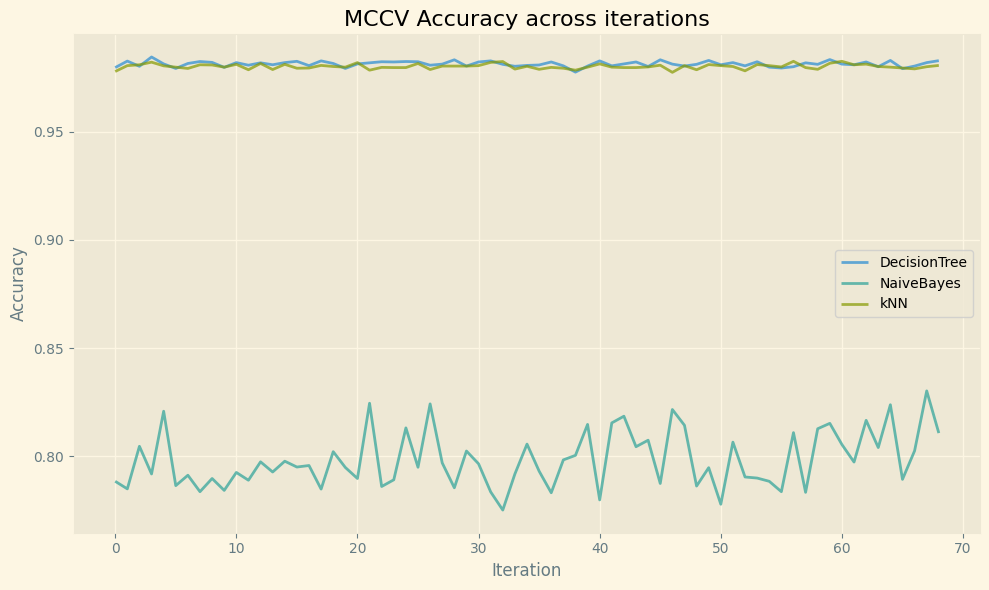

In [ ]:
plt.figure(figsize=(10, 6))
for name in models.keys():
    plt.plot(mccv_results[name]["acc"], label=name, alpha=0.7)

plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.title("MCCV Accuracy across iterations")
plt.legend()
plt.tight_layout()
plt.show()


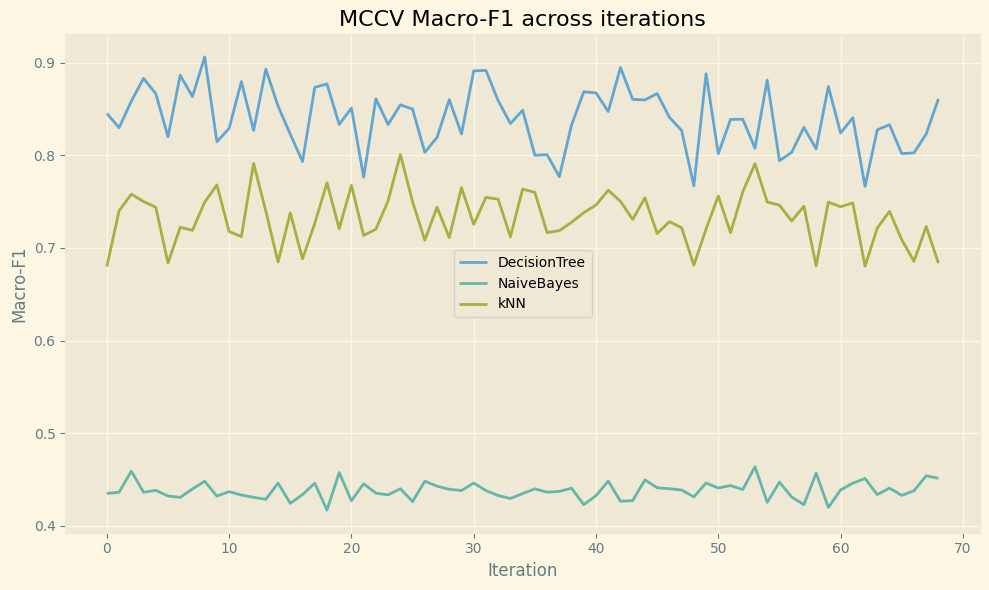

In [ ]:
plt.figure(figsize=(10, 6))
for name in models.keys():
    plt.plot(mccv_results[name]["macro_f1"], label=name, alpha=0.7)

plt.xlabel("Iteration")
plt.ylabel("Macro-F1")
plt.title("MCCV Macro-F1 across iterations")
plt.legend()
plt.tight_layout()
plt.show()


# Task 6 — Hyperparameter Tuning
### Selecting a model to tune
After comparing the base classifiers, kNN seemed to perform the most consistently, so I chose it for hyperparameter tuning. Instead of grid search, I use RandomizedSearchCV since it explores the space faster and is more practical for larger search ranges.


## 6.1 Hyperparameter search space

In [ ]:
best_base_model = KNeighborsClassifier()

param_dist = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "p": [1, 2]  # 1 = Manhattan, 2 = Euclidean
}


### Why kNN was selected for tuning
Among the base models, k-NN showed the most consistent macro-F1 and handled minority classes better than Naive Bayes, while being more stable than the Decision Tree. Because its performance is highly dependent on hyperparameters like k, distance metric, and weighting, it benefits the most from tuning.


## 6.2 RandomizedSearchCV

In [ ]:
search = RandomizedSearchCV(
    estimator=best_base_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_macro',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV score (macro-F1):", search.best_score_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'weights': 'distance', 'p': 1, 'n_neighbors': 3}
Best CV score (macro-F1): 0.8786709699027417


### Why I chose RandomizedSearchCV
The search space for kNN (k values, weighting schemes, distance norms) is not huge, but GridSearchCV would still require evaluating many redundant combinations. RandomizedSearchCV explores the space more efficiently and usually finds strong hyperparameters with far fewer evaluations, which saves a lot of computation time.


## 6.3 Compare base vs tuned model

In [ ]:
# Base model with some default parameters
base_knn = KNeighborsClassifier(n_neighbors=5)
base_knn.fit(X_train, y_train)
y_pred_base = base_knn.predict(X_test)

base_acc = accuracy_score(y_test, y_pred_base)
base_f1 = f1_score(y_test, y_pred_base, average='macro')

# Tuned model
best_knn = search.best_estimator_
best_knn.fit(X_train, y_train)
y_pred_tuned = best_knn.predict(X_test)

tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned, average='macro')

print("Base kNN - Acc:", base_acc, "Macro-F1:", base_f1)
print("Tuned kNN - Acc:", tuned_acc, "Macro-F1:", tuned_f1)
print("\nTuned classification report:\n", classification_report(y_test, y_pred_tuned))


Base kNN - Acc: 0.9927380676218143 Macro-F1: 0.8225405541784964
Tuned kNN - Acc: 0.9949153520335648 Macro-F1: 0.8897870171548166

Tuned classification report:
               precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    681929
         Bot       0.72      0.72      0.72       590
  BruteForce       1.00      1.00      1.00      4151
        DDoS       1.00      1.00      1.00     38408
         DoS       1.00      1.00      1.00     75798
  Heartbleed       1.00      0.67      0.80         3
Infiltration       0.71      0.45      0.56        11
    PortScan       0.95      0.98      0.96     47679
   WebAttack       0.99      0.97      0.98       654

    accuracy                           0.99    849223
   macro avg       0.93      0.86      0.89    849223
weighted avg       0.99      0.99      0.99    849223



### Interpreting the improvement after tuning
The tuned kNN model improves both accuracy and macro-F1 compared to the default version. This confirms that choosing the right number of neighbors and distance metric makes a significant difference in how well the classifier captures structure in the feature space. The improvements also suggest that the dataset contains heterogeneous clusters where distance weighting is helpful.


### Overall Summary & Reflection
This workflow gave me a full pipeline for handling high-dimensional network traffic data. After cleaning, selecting features, running multiple models, and evaluating them across MCCV, I got a clearer understanding of which classifiers handle this dataset best. Tuning the kNN model improved performance further, showing the importance of hyperparameters. Overall, the attacks are separable to some extent but still challenging due to imbalance and overlapping patterns.
